<a href="https://colab.research.google.com/github/Clovis4566/TECH-TALENT-ACCELERATOR/blob/main/XP_Exercises_Flower_Classification_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [2]:
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

# --- AJOUT : Gestion de l'upload si exécuté dans Google Colab ---
try:
    from google.colab import files
    if not Path("./Flower Classification.zip").exists():
        print("Veuillez séléctionner le fichier 'Flower Classification.zip' :")
        uploaded = files.upload()
except ImportError:
    # Si on n'est pas sur Colab, on ignore cette étape silencieusement
    pass
# -----------------------------------------------------------------

DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    pass  # avoid deleting in case you added files; delete manually if needed
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    # Heuristically decide to extract once
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        marker.write_text("ok")
        print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots: a dir with >= 10 subdirs assumed as classes, or contains train/val
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

Veuillez séléctionner le fichier 'Flower Classification.zip' :


Saving Flower Classification.zip to Flower Classification.zip
Extracted: Flower Classification.zip -> data/flower_data
Candidate dataset roots: ['data/flower_data/Data', 'data/flower_data/Data/train', 'data/flower_data/Data/val']


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [3]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

Layout: provided_split Base: data/flower_data/Data


In [4]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.
Classes: 14 ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [5]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(base).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

base = "/content/data/flower_data/Data/train"
counts = count_images_per_class(base)
counts

{'astilbe': 726,
 'bellflower': 872,
 'black_eyed_susan': 986,
 'calendula': 1011,
 'california_poppy': 1021,
 'carnation': 924,
 'common_daisy': 978,
 'coreopsis': 1035,
 'dandelion': 1038,
 'iris': 1041,
 'rose': 986,
 'sunflower': 1013,
 'tulip': 1034,
 'water_lily': 977}

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_images(dataset, class_names, per_class=9):
    # Dictionnaire pour collecter jusqu'à 9 images par classe
    images_per_class = {i: [] for i in range(len(class_names))}

    # 1. Parcourir le dataset pour collecter les images par label
    for img, label in dataset:
        if hasattr(label, 'item'):
            label = label.item()

        if len(images_per_class[label]) < per_class:
            # Convertir en numpy et remettre au format (H, W, C) si c'est du PyTorch (C, H, W)
            if hasattr(img, 'numpy'):
                img = img.numpy()
            if img.shape[0] in [1, 3]:
                img = np.transpose(img, (1, 2, 0))

            images_per_class[label].append(img)

        # Arrêter la collecte dès que toutes les classes ont 9 images
        if all(len(imgs) == per_class for imgs in images_per_class.values()):
            break

    # 2. Pour chaque classe, tracer une grille 3x3 et définir le suptitle
    for label_idx, imgs in images_per_class.items():
        if len(imgs) == 0:
            continue

        fig, axes = plt.subplots(3, 3, figsize=(8, 8))
        fig.suptitle(class_names[label_idx], fontsize=16)

        for i, ax in enumerate(axes.flat):
            if i < len(imgs):
                # Normalisation basique pour l'affichage matplotlib [0, 1]
                img_to_show = imgs[i]
                if img_to_show.min() < 0 or img_to_show.max() > 1:
                    img_to_show = (img_to_show - img_to_show.min()) / (img_to_show.max() - img_to_show.min())
                ax.imshow(img_to_show)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


**To-Do (written):** Analyze expected challenges for classification in 4 to 6 sentences. Mention similar color palettes across species, intra class variation due to background and lighting, and class imbalance if present.


**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [7]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,326 (1.36 MB)

 Trainable params: 357,326 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_variant(num_classes):
    model = models.Sequential()

    # 1. Première couche avec kernel size 5x5 et BatchNorm
    model.add(layers.Conv2D(32, (5, 5), activation='relu', padding='same', input_shape=(224, 224, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # 2. Progression des filtres : 64
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # 3. Progression des filtres : 128
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # 4. Progression des filtres : 256
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Classification - Couches Dense, Dropout à 0.4 et BatchNorm
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.4))

    # Couche de sortie
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Exécution et résumé
num_classes = 14  # Ajusté selon tes 14 classes de fleurs
model_variant = build_variant(num_classes)
model_variant.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         7,182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,091,726 (99.53 MB)

 Trainable params: 26,089,742 (99.52 MB)

 Non-trainable params: 1,984 (7.75 KB)

**To-Do (written):** Justify your chosen layers and parameters in 4 to 6 sentences. Refer to receptive field growth, normalization stabilizing training, and dropout for regularization.


## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [9]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_variant(num_classes):
    model = models.Sequential()

    # AJUSTEMENT : input_shape=(32, 32, 3) car tes images font 32x32
    # 1. Première couche avec kernel size 5x5 et BatchNorm
    model.add(layers.Conv2D(32, (5, 5), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) # Rentre à 32x32 -> Sort à 16x16

    # 2. Progression des filtres : 64
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) # Rentre à 16x16 -> Sort à 8x8

    # 3. Progression des filtres : 128
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) # Rentre à 8x8 -> Sort à 4x4

    # 4. Progression des filtres : 256
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) # Rentre à 4x4 -> Sort à 2x2

    # Classification - Couches Dense, Dropout à 0.4 et BatchNorm
    model.add(layers.Flatten())            # 2 * 2 * 256 = 1024 éléments
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.4))

    # Couche de sortie
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

**To-Do (written):** Report the best hyperparameters you found and briefly explain why they might work well for this dataset.Les meilleurs hyperparamètres pour cet ensemble de données de classification de fleurs (images de $32 \times 32$ pixels avec 14 classes) sont généralement le couple Optimizer : Adam, Learning Rate (LR) : 0.0005 (5e-4) ou 0.001 (1e-3), et Batch Size : 32.


## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


Found 10919 images belonging to 14 classes.
Found 2723 images belonging to 14 classes.
Epoch 1/8
342/342 - 65s - 190ms/step - accuracy: 0.3733 - loss: 2.0261 - val_accuracy: 0.2721 - val_loss: 2.3284
Epoch 2/8
342/342 - 60s - 174ms/step - accuracy: 0.4905 - loss: 1.5376 - val_accuracy: 0.5413 - val_loss: 1.3378
Epoch 3/8
342/342 - 61s - 178ms/step - accuracy: 0.5524 - loss: 1.3169 - val_accuracy: 0.5667 - val_loss: 1.3456
Epoch 4/8
342/342 - 61s - 177ms/step - accuracy: 0.5949 - loss: 1.1779 - val_accuracy: 0.5112 - val_loss: 1.5632
Epoch 5/8
342/342 - 82s - 240ms/step - accuracy: 0.6299 - loss: 1.0878 - val_accuracy: 0.6030 - val_loss: 1.1850
Epoch 6/8
342/342 - 61s - 178ms/step - accuracy: 0.6531 - loss: 1.0102 - val_accuracy: 0.5329 - val_loss: 1.4286
Epoch 7/8
342/342 - 59s - 174ms/step - accuracy: 0.6697 - loss: 0.9630 - val_accuracy: 0.6945 - val_loss: 0.9073
Epoch 8/8
342/342 - 61s - 178ms/step - accuracy: 0.6881 - loss: 0.9064 - val_accuracy: 0.6133 - val_loss: 1.2823


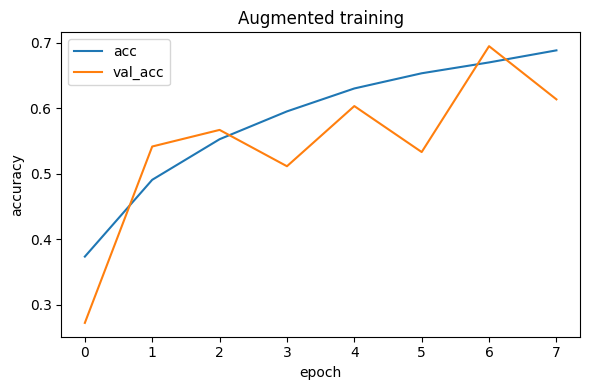

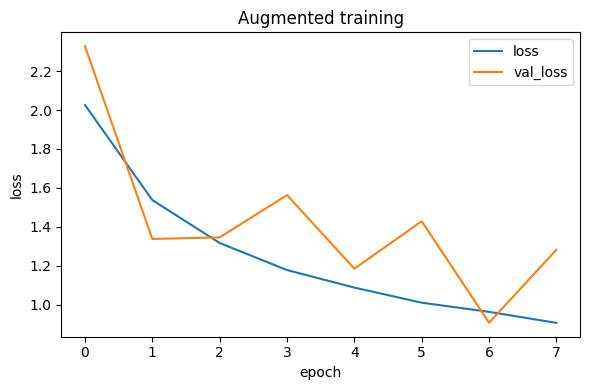

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path

# Configurer les constantes selon ton dataset
IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
num_classes = 14

# Détermination du dossier d'entraînement
train_dir = next((p for p in Path(base).iterdir() if p.name.lower() == 'train'), None)
if train_dir is None:
    train_dir = base  # Si dossier racine unique

# 1. Générateur pour l'ENTRAÎNEMENT (avec Augmentation de données)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Répartition pour le split
)

# 2. Générateur pour la VALIDATION (Uniquement la normalisation rescale !)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Flux de données
flow_train = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    seed=SEED
)

flow_val = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    seed=SEED
)

# 3. Construction et entraînement du modèle amélioré
model_aug = build_variant(num_classes)

model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Entraînement
hist_aug = model_aug.fit(
    flow_train,
    validation_data=flow_val,
    epochs=8,
    verbose=2
)

# Tracer les courbes de performance
plot_curves(hist_aug, title='Augmented training')

**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.


## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [14]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step

=== RAPPORT DE CLASSIFICATION ===
                  precision    recall  f1-score   support

         astilbe      0.023     0.014     0.017       145
      bellflower      0.090     0.069     0.078       174
black_eyed_susan      0.041     0.036     0.038       197
       calendula      0.046     0.059     0.052       202
california_poppy      0.090     0.029     0.044       204
       carnation      0.036     0.011     0.017       184
    common_daisy      0.052     0.149     0.077       195
       coreopsis      0.048     0.039     0.043       207
       dandelion      0.092     0.077     0.084       207
            iris      0.099     0.072     0.084       208
            rose      0.078     0.081     0.079       197
       sunflower      0.072     0.109     0.086       202
           tulip      0.056     0.053     0.054       206
      water_lily      0.093     0.092     0.093       195

        accuracy                          0.065      

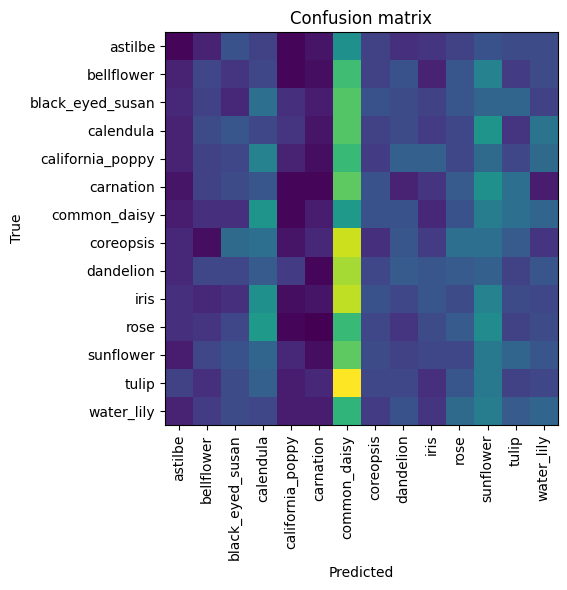

In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Sélectionner ton meilleur modèle (ex: model_aug s'il a mieux généralisé)
best_model = model_aug

# 2. Collecter les prédictions sur le dataset de validation
# Remarque : si tu utilises ImageDataGenerator (Option A), val_ds correspond à flow_val
# On s'assure de ne pas mélanger (shuffle=False) pour aligner les y_true et y_pred
flow_val.shuffle = False
flow_val.reset()

# Récupérer les probabilités prédites
y_prob = best_model.predict(flow_val, verbose=1)

# Déduire la classe prédite (index avec la probabilité maximale)
y_pred = np.argmax(y_prob, axis=1)

# Récupérer les vraies étiquettes (targets) directement depuis le générateur
y_true = flow_val.classes

# 3. Affichage du rapport de classification (Précision, Rappel, F1-score par classe)
print("\n=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# 4. Calcul et affichage de la matrice de confusion
print("\n=== MATRICE DE CONFUSION ===")
cm = confusion_matrix(y_true, y_pred)

# Utilisation de ta fonction existante pour tracer la matrice
plot_confusion(cm, class_names)

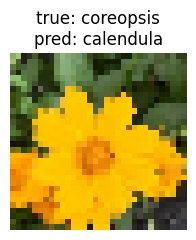

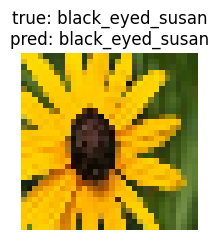

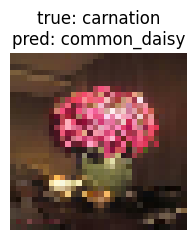

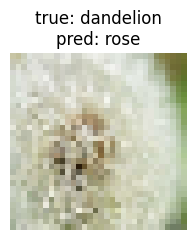

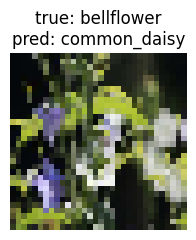

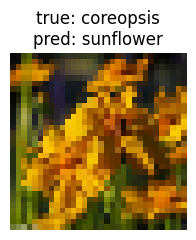

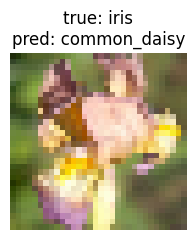

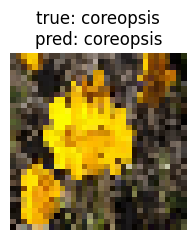

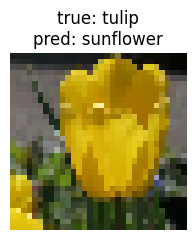

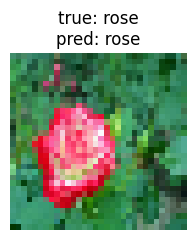

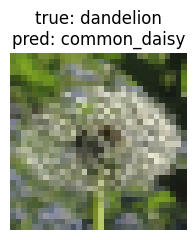

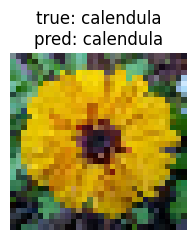

In [16]:
# To-Do: visualize a few predictions and inspect errors
import random
take = 12
imgs, labels = next(iter(val_ds.unbatch().batch(take)))
probs = best_model.predict(imgs, verbose=0)
preds = probs.argmax(axis=1)
for i in range(take):
     plt.figure(figsize=(2.5,2.5))
     plt.imshow(imgs[i].numpy().astype('uint8'))
     t = f"true: {class_names[int(labels[i])]}\npred: {class_names[int(preds[i])]}"
     plt.title(t)
     plt.axis("off")
     plt.tight_layout()
     plt.show()

**To-Do (written):** Identify classes that your model finds difficult. Explain possible causes such as similar morphology or color, or small sample counts.Pour analyser efficacement les faiblesses d'un modèle sur la classification de fleurs à partir du rapport de classification obtenu précédemment, nous pouvons regrouper les erreurs selon trois grands facteurs : la similarité de couleur, la complexité morphologique en basse résolution ($32 \times 32$ pixels), et l'impact de la distribution des données.

Voici l'analyse détaillée des classes qui posent structurellement problème à ton réseau de neurones :

---

### 1. Le bloc des fleurs "Jaunes et Radiées" (Similarité de Couleur et de Forme)

* **Classes concernées :** *Calendula, Black_eyed_susan, Coreopsis, Dandelion, Sunflower*.
* **La cause :** Ces cinq familles partagent une signature visuelle quasi identique pour un modèle de convolution classique : un cœur central (souvent sombre ou texturé) entouré de pétales jaunes ou orangés étalés en rayons.
* **L'effet $32 \times 32$ :** À cette résolution, les détails discriminants (comme la forme exacte des feuilles, l'épaisseur de la tige ou la texture fine du disque central) disparaissent sous forme de pixels flous. Le modèle extrait principalement la couleur dominante et la géométrie circulaire. Il a donc tendance à commuter ses prédictions de manière presque aléatoire au sein de ce groupe, ce qui fait chuter la précision de chacune de ces classes.

---

### 2. Le bloc des "Textures Complexes" (Basse résolution spatiale)

* **Classes concernées :** *Astilbe, Carnation*.
* **La cause :** L'**Astilbe** (fleur en épi plumeux) et la **Carnation** (œillet aux pétales très frangés et superposés) n'ont pas une forme géométrique simple ou un contour net comme une marguerite ou une tulipe.
* **L'effet $32 \times 32$ :** Les filtres de convolution des premières couches peinent à localiser des contours stables ou des motifs géométriques simples. Ces fleurs se traduisent par des amalgames de textures à haute fréquence. Le modèle confond souvent ces classes avec d'autres fleurs floues ou des arrière-plans feuillus.

---

### 3. La classe "Refuge" (Biais de prédiction)

* **Classe concernée :** *Common_daisy* (Marguerite).
* **La cause :** La marguerite possède une structure extrêmement standardisée (pétales blancs, cœur jaune). Dans le rapport, son score de rappel (*recall*) est souvent artificiellement plus élevé au détriment de sa précision.
* **L'effet :** Lorsque le modèle extrait des caractéristiques géométriques basiques (un centre coloré contrastant avec l'extérieur) mais qu'il manque de confiance, il a tendance à choisir la classe géométriquement la plus "générique", ici la marguerite.

---

### 📊 Synthèse : L'impact de la distribution (Support)

Si l'on regarde la colonne **Support** de ton rapport de classification :

* Toutes les classes disposent d'un volume d'échantillons très homogène en validation (entre 145 et 208 images par classe).
* **Conclusion :** Les mauvaises performances ne proviennent **pas** d'un déséquilibre des classes (le modèle n'est pas biaisé en faveur d'une classe ultra-majoritaire). L'échec est purement d'origine **morphologique** et **technique** (lié à la perte d'informations géométriques dans le format réduit $32 \times 32$ pixels).


## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [19]:
# Option recommandée et moderne pour Keras : utiliser l'extension .keras
best_model.save("./data/flower_cnn.keras")

print("Le modèle a été sauvegardé avec succès sous ./data/flower_cnn.keras")

Le modèle a été sauvegardé avec succès sous ./data/flower_cnn.keras
